# 🔍 Credit Card Fraud Detection
## Anomaly Detection & Supervised Learning Pipeline

---

### Project Overview

This notebook implements a comprehensive fraud detection system using:
- **Anomaly Detection**: Isolation Forest & Local Outlier Factor (LOF)
- **Supervised Learning**: XGBoost with hyperparameter tuning
- **Evaluation**: ROC curves, confusion matrices, precision-recall curves, and a final metrics summary table
- **Deployment**: A Streamlit dashboard for real-time fraud prediction

### Dataset
Kaggle Credit Card Fraud Detection dataset (`creditcard.csv`):  
- 284,807 transactions across 2 days  
- 492 frauds (~0.17% of all transactions) — highly imbalanced  
- Features V1–V28 are PCA-transformed (anonymised); `Time` and `Amount` are original  
- Target: `Class` (1 = Fraud, 0 = Legitimate)

### Key Principles for Imbalanced Datasets
- ✅ **Never** test on the oversampled/undersampled dataset
- ✅ Apply SMOTE **inside** cross-validation folds, not before
- ✅ Use **F1, Precision, Recall, ROC-AUC** — NOT plain accuracy

---

## Outline
1. **Setup & Data Loading**
2. **Exploratory Data Analysis**
3. **Preprocessing & Feature Scaling**
4. **Train/Test Split**
5. **Anomaly Detection — Isolation Forest**
6. **Anomaly Detection — Local Outlier Factor (LOF)**
7. **Supervised Learning — XGBoost with Hyperparameter Tuning**
8. **Comprehensive Model Evaluation**
9. **Final Metrics Comparison Table**
10. **Save Model & Generate Streamlit App**

---
## 1. Setup & Library Imports

In [28]:
# ============================================================
# CELL 1: Install / verify required packages
# ============================================================
# Uncomment the line below if any package is missing:
# !pip install xgboost imbalanced-learn scikit-learn pandas numpy matplotlib seaborn joblib streamlit

# ── Core Libraries ──────────────────────────────────────────
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# ── Visualisation ───────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# ── Preprocessing ───────────────────────────────────────────
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    RandomizedSearchCV, cross_val_score
)

# ── Anomaly Detection ────────────────────────────────────────
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

# ── Supervised Classifier ───────────────────────────────────
from xgboost import XGBClassifier

# ── Imbalanced Learning ──────────────────────────────────────
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# ── Metrics ─────────────────────────────────────────────────
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    f1_score, precision_score, recall_score
)

# ── Model Persistence ───────────────────────────────────────
import joblib
import os
import json

# ── Create directory for graphs ─────────────────────────────
os.makedirs('Graphs', exist_ok=True)

# ── Reproducibility ─────────────────────────────────────────
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ── Plot Styling ─────────────────────────────────────────────
plt.style.use('seaborn-v0_8-darkgrid')
COLORS = {
    'fraud':   '#e74c3c',
    'legit':   '#2ecc71',
    'primary': '#3498db',
    'if':      '#9b59b6',
    'lof':     '#e67e22',
    'xgb':     '#1abc9c',
}

print('✅ All libraries imported successfully.')
print(f'   numpy  : {np.__version__}')
print(f'   pandas : {pd.__version__}')

✅ All libraries imported successfully.
   numpy  : 2.4.6
   pandas : 3.0.3


---
## 2. Data Loading & Initial Exploration

In [29]:
# ============================================================
# CELL 2: Load the dataset
# ============================================================
# Adjust the path if your CSV is in a different location
DATA_PATH = 'creditcard.csv'

df = pd.read_csv(DATA_PATH)
print(f'Dataset shape : {df.shape}')
print(f'Memory usage  : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')
df.head()

Dataset shape : (284807, 31)
Memory usage  : 70.6 MB


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [30]:
# ============================================================
# CELL 3: Basic statistics
# ============================================================
df.describe().T[['mean', 'std', 'min', 'max']].round(3)

,mean,std,min,max
Time,94813.860,47488.146,0.000,172792.000
V1,0.000,1.959,-56.408,2.455
V2,0.000,1.651,-72.716,22.058
V3,-0.000,1.516,-48.326,9.383
V4,0.000,1.416,-5.683,16.875
V5,0.000,1.380,-113.743,34.802
V6,0.000,1.332,-26.161,73.302
V7,-0.000,1.237,-43.557,120.589
V8,0.000,1.194,-73.217,20.007
V9,-0.000,1.099,-13.434,15.595


In [31]:
# ============================================================
# CELL 4: Null-value check & class distribution
# ============================================================
print('Null values per column:')
print(df.isnull().sum().max(), '← (max nulls; 0 = no missing data)\n')

fraud_count = df['Class'].sum()
legit_count = len(df) - fraud_count
total       = len(df)

print('Class Distribution')
print('──────────────────')
print(f'  Legitimate : {legit_count:,}  ({legit_count/total*100:.2f}%)')
print(f'  Fraud      : {fraud_count:,}   ({fraud_count/total*100:.4f}%)')
print(f'  Imbalance ratio : {legit_count/fraud_count:.0f}:1')

Null values per column:
0 ← (max nulls; 0 = no missing data)

Class Distribution
──────────────────
  Legitimate : 284,315  (99.83%)
  Fraud      : 492   (0.1727%)
  Imbalance ratio : 578:1


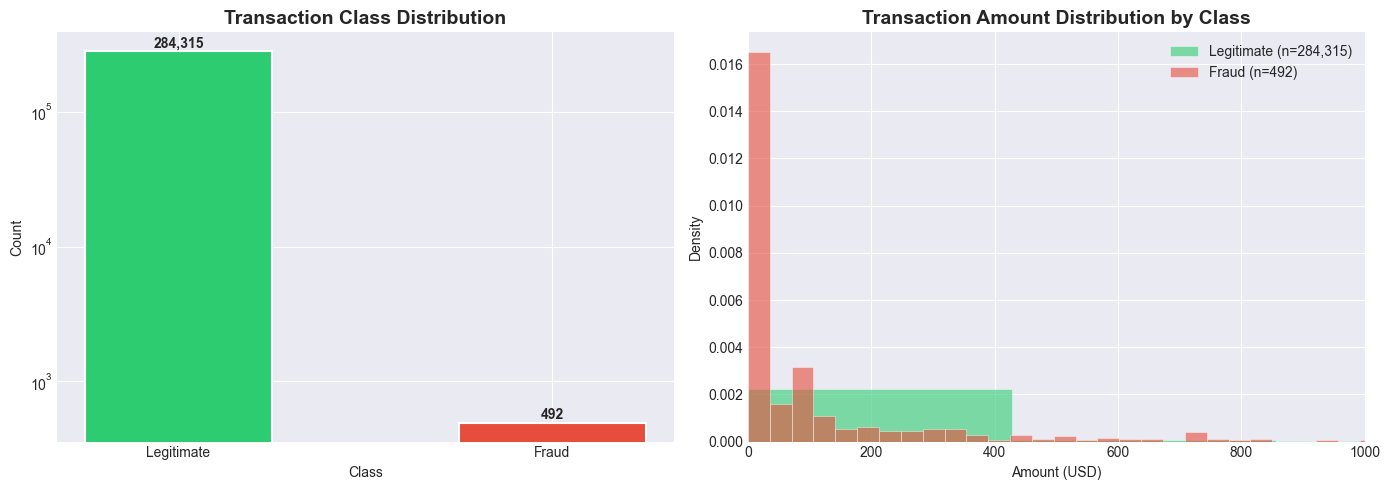

Figure saved: Graphs/class_distribution.png


In [32]:
# ============================================================
# CELL 5: Class imbalance visualisation
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Bar chart ──────────────────────────────────────────────
counts = df['Class'].value_counts()
bars = axes[0].bar(
    ['Legitimate', 'Fraud'],
    [counts[0], counts[1]],
    color=[COLORS['legit'], COLORS['fraud']],
    edgecolor='white', linewidth=1.5, width=0.5
)
for bar, count in zip(bars, [counts[0], counts[1]]):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() * 1.01,
        f'{count:,}', ha='center', va='bottom', fontweight='bold'
    )
axes[0].set_title('Transaction Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].set_yscale('log')
axes[0].set_xlabel('Class')

# ── Amount distribution by class ───────────────────────────
for cls, color, label in [(0, COLORS['legit'], 'Legitimate'), (1, COLORS['fraud'], 'Fraud')]:
    subset = df[df['Class'] == cls]['Amount']
    axes[1].hist(subset, bins=60, alpha=0.6, color=color, label=f'{label} (n={len(subset):,})',
                 density=True, edgecolor='white', linewidth=0.5)
axes[1].set_xlim(0, 1000)
axes[1].set_title('Transaction Amount Distribution by Class', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Amount (USD)')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.tight_layout()
plt.savefig('Graphs/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: Graphs/class_distribution.png')

---
## 3. Preprocessing & Feature Scaling

**Strategy:**  
- `Amount` and `Time` are on very different scales from V1–V28 (which are already PCA-transformed)  
- Apply `RobustScaler` (robust to outliers via IQR) to `Amount` and `Time`  
- Overwrite the originals with scaled versions

In [33]:
# ============================================================
# CELL 6: Scale Amount and Time with RobustScaler
# ============================================================
rob_scaler = RobustScaler()

df['scaled_amount'] = rob_scaler.fit_transform(df['Amount'].values.reshape(-1, 1))
df['scaled_time']   = rob_scaler.fit_transform(df['Time'].values.reshape(-1, 1))

# Drop the original (unscaled) columns — keep a clean feature set
df_scaled = df.drop(['Time', 'Amount'], axis=1)

# Re-order: put scaled_amount and scaled_time at the front
cols = ['scaled_amount', 'scaled_time'] + [c for c in df_scaled.columns if c not in ['scaled_amount', 'scaled_time', 'Class']] + ['Class']
df_scaled = df_scaled[cols]

print('Scaled dataset shape:', df_scaled.shape)
df_scaled.head(3)

Scaled dataset shape: (284807, 31)


,scaled_amount,scaled_time,V1,V2,V3,V4,V5,V6,V7,V8,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Class
0,1.783274,-0.994983,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0
1,-0.269825,-0.994983,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0
2,4.983721,-0.994972,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,...,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0


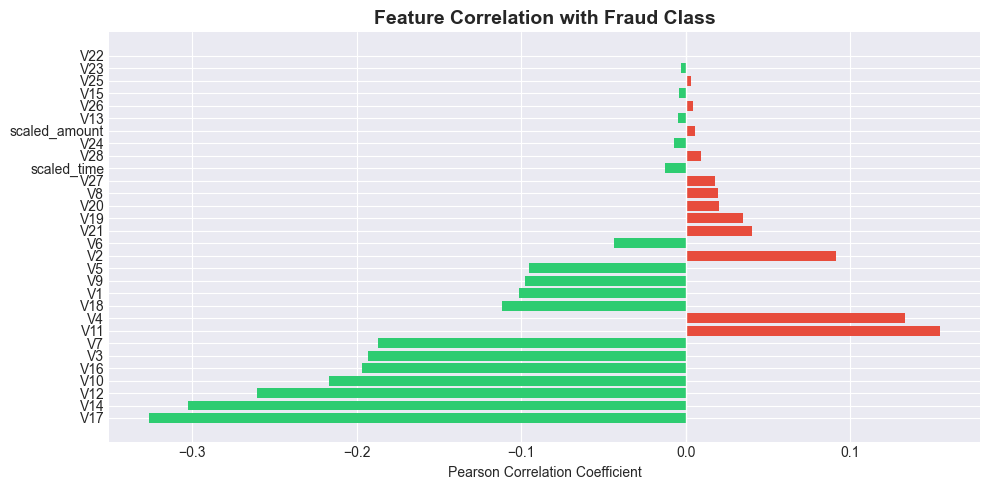

Top positively correlated with fraud: ['V17', 'V14', 'V12', 'V10', 'V16']
Top negatively correlated with fraud: ['V26', 'V15', 'V25', 'V23', 'V22']


In [34]:
# ============================================================
# CELL 7: Correlation heatmap — fraud vs. non-fraud features
# ============================================================
# Compute separate correlation matrices
fraud_corr = df_scaled[df_scaled['Class'] == 1].corr()
legit_corr = df_scaled[df_scaled['Class'] == 0].corr()

# Top features correlated with Class
class_corr = df_scaled.corr()['Class'].drop('Class').sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
colors = [COLORS['fraud'] if v > 0 else COLORS['legit'] for v in class_corr.values]
ax.barh(class_corr.index, class_corr.values, color=colors)
ax.axvline(0, color='white', linewidth=1)
ax.set_title('Feature Correlation with Fraud Class', fontsize=14, fontweight='bold')
ax.set_xlabel('Pearson Correlation Coefficient')
plt.tight_layout()
plt.savefig('Graphs/feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Top positively correlated with fraud:', class_corr.head(5).index.tolist())
print('Top negatively correlated with fraud:', class_corr.tail(5).index.tolist())

---
## 4. Train / Test Split

We split **once** on the original (imbalanced) data.  
- The test set is **never touched** by resampling methods  
- SMOTE is applied **only** to the training fold during cross-validation for XGBoost

In [35]:
# ============================================================
# CELL 8: Stratified train/test split (80/20)
# ============================================================
X = df_scaled.drop('Class', axis=1)
y = df_scaled['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y          # preserve fraud ratio in both splits
)

print(f'Training set   : {X_train.shape[0]:,} samples')
print(f'Test set       : {X_test.shape[0]:,} samples')
print(f'Train fraud %  : {y_train.mean()*100:.4f}%')
print(f'Test  fraud %  : {y_test.mean()*100:.4f}%')

# Feature list stored for the Streamlit app
FEATURE_NAMES = list(X.columns)
print(f'\nFeatures ({len(FEATURE_NAMES)}):', FEATURE_NAMES)

Training set   : 227,845 samples
Test set       : 56,962 samples
Train fraud %  : 0.1729%
Test  fraud %  : 0.1720%

Features (30): ['scaled_amount', 'scaled_time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28']


---
## 5. Anomaly Detection — Isolation Forest

**How it works:**  
Isolation Forest builds an ensemble of random trees and measures how quickly a sample is isolated.  
Anomalies (fraud) are isolated with **fewer splits** → shorter path length → lower score.

**Training strategy:**  
- Train **only on the majority class** (non-fraud) from the training set  
- This makes it an unsupervised approach; it learns what "normal" looks like  
- Then predict on the **full test set** (fraud + non-fraud)

In [36]:
# ============================================================
# CELL 9: Train Isolation Forest on non-fraud transactions only
# ============================================================
print('Training Isolation Forest on non-fraud transactions...')

# Select only legitimate transactions for training
X_train_legit = X_train[y_train == 0]
print(f'  Training on {len(X_train_legit):,} legitimate transactions')

# contamination = approximate fraction of fraud in the overall dataset
fraud_fraction = y.mean()  # ≈ 0.0017

iso_forest = IsolationForest(
    n_estimators=200,          # more trees → more stable scores
    contamination=fraud_fraction,
    max_samples='auto',
    random_state=RANDOM_STATE,
    n_jobs=-1                  # use all CPU cores
)
iso_forest.fit(X_train_legit)
print('✅ Isolation Forest trained.')

# ── Predict on full test set ────────────────────────────────
# predict() returns +1 (inlier/normal) or -1 (outlier/anomaly)
if_raw_pred = iso_forest.predict(X_test)          # +1 or -1
if_pred     = np.where(if_raw_pred == -1, 1, 0)   # convert: -1→1(fraud), +1→0(legit)

# Anomaly scores (lower = more anomalous)
if_scores = iso_forest.decision_function(X_test)   # raw anomaly score
# Invert and normalise to [0,1] for use as a fraud probability proxy
if_scores_norm = 1 - (if_scores - if_scores.min()) / (if_scores.max() - if_scores.min())

print(f'\nFraud detected  : {if_pred.sum()}')
print(f'Actual fraud    : {y_test.sum()}')

Training Isolation Forest on non-fraud transactions...
  Training on 227,451 legitimate transactions
✅ Isolation Forest trained.

Fraud detected  : 128
Actual fraud    : 98


In [37]:
# ============================================================
# CELL 10: Isolation Forest — Evaluation
# ============================================================
print('=' * 60)
print('ISOLATION FOREST — Classification Report')
print('=' * 60)
print(classification_report(y_test, if_pred, target_names=['Legitimate', 'Fraud']))

# Store metrics for the final summary table
if_precision = precision_score(y_test, if_pred, zero_division=0)
if_recall    = recall_score(y_test, if_pred, zero_division=0)
if_f1        = f1_score(y_test, if_pred, zero_division=0)
if_roc_auc   = roc_auc_score(y_test, if_scores_norm)

print(f'ROC-AUC Score    : {if_roc_auc:.4f}')
print(f'Precision (fraud): {if_precision:.4f}')
print(f'Recall    (fraud): {if_recall:.4f}')
print(f'F1-Score  (fraud): {if_f1:.4f}')

ISOLATION FOREST — Classification Report
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.21      0.28      0.24        98

    accuracy                           1.00     56962
   macro avg       0.60      0.64      0.62     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC Score    : 0.9523
Precision (fraud): 0.2109
Recall    (fraud): 0.2755
F1-Score  (fraud): 0.2389


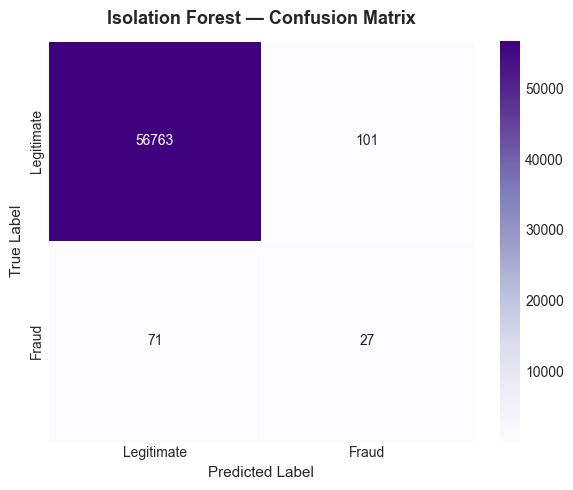

In [38]:
# ============================================================
# CELL 11: Isolation Forest — Confusion Matrix
# ============================================================
def plot_confusion_matrix(cm, title, ax, cmap='Blues'):
    """Helper to plot a labelled confusion matrix."""
    sns.heatmap(
        cm, annot=True, fmt='d', cmap=cmap,
        xticklabels=['Legitimate', 'Fraud'],
        yticklabels=['Legitimate', 'Fraud'],
        ax=ax, linewidths=0.5, linecolor='white'
    )
    ax.set_title(title, fontsize=13, fontweight='bold', pad=12)
    ax.set_xlabel('Predicted Label', fontsize=11)
    ax.set_ylabel('True Label', fontsize=11)

cm_if = confusion_matrix(y_test, if_pred)
fig, ax = plt.subplots(figsize=(6, 5))
plot_confusion_matrix(cm_if, 'Isolation Forest — Confusion Matrix', ax, cmap='Purples')
plt.tight_layout()
plt.savefig('Graphs/cm_isolation_forest.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Anomaly Detection — Local Outlier Factor (LOF)

**How it works:**  
LOF compares the **local density** of a point to its *k* nearest neighbours.  
A point with a much lower density than its neighbours is flagged as an outlier (potential fraud).

**Note:** LOF with `novelty=True` allows us to train on non-fraud only and score new test points.  
However, `novelty=False` LOF is computationally cheaper — we use `novelty=True` here for a proper train/test setup.

> ⚠️ **Resource note:** LOF with `novelty=True` on the full training set can be slow.  
> A sample of 10,000 non-fraud transactions is used for efficiency in limited environments.

In [39]:
# ============================================================
# CELL 12: Train LOF (novelty mode) on non-fraud only
# ============================================================
print('Training Local Outlier Factor...')

# Sample non-fraud training data for efficiency
MAX_LOF_SAMPLES = 10_000
X_train_legit_lof = X_train[y_train == 0]
if len(X_train_legit_lof) > MAX_LOF_SAMPLES:
    X_train_legit_lof = X_train_legit_lof.sample(
        MAX_LOF_SAMPLES, random_state=RANDOM_STATE
    )
    print(f'  Sampled {MAX_LOF_SAMPLES:,} non-fraud transactions for efficiency')
else:
    print(f'  Using all {len(X_train_legit_lof):,} non-fraud training samples')

lof = LocalOutlierFactor(
    n_neighbors=20,
    algorithm='auto',
    contamination=fraud_fraction,
    novelty=True,          # allows predict() on new data
    n_jobs=-1
)
lof.fit(X_train_legit_lof)
print('✅ LOF trained.')

# ── Predict on test set ─────────────────────────────────────
lof_raw_pred = lof.predict(X_test)               # +1 or -1
lof_pred     = np.where(lof_raw_pred == -1, 1, 0) # -1→1(fraud), +1→0(legit)

# LOF scores (more negative = more anomalous)
lof_scores      = lof.decision_function(X_test)
lof_scores_norm = 1 - (lof_scores - lof_scores.min()) / (lof_scores.max() - lof_scores.min())

print(f'\nFraud detected  : {lof_pred.sum()}')
print(f'Actual fraud    : {y_test.sum()}')

Training Local Outlier Factor...
  Sampled 10,000 non-fraud transactions for efficiency
✅ LOF trained.

Fraud detected  : 200
Actual fraud    : 98


In [40]:
# ============================================================
# CELL 13: LOF — Evaluation
# ============================================================
print('=' * 60)
print('LOCAL OUTLIER FACTOR — Classification Report')
print('=' * 60)
print(classification_report(y_test, lof_pred, target_names=['Legitimate', 'Fraud']))

lof_precision = precision_score(y_test, lof_pred, zero_division=0)
lof_recall    = recall_score(y_test, lof_pred, zero_division=0)
lof_f1        = f1_score(y_test, lof_pred, zero_division=0)
lof_roc_auc   = roc_auc_score(y_test, lof_scores_norm)

print(f'ROC-AUC Score    : {lof_roc_auc:.4f}')
print(f'Precision (fraud): {lof_precision:.4f}')
print(f'Recall    (fraud): {lof_recall:.4f}')
print(f'F1-Score  (fraud): {lof_f1:.4f}')

LOCAL OUTLIER FACTOR — Classification Report
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.38      0.78      0.51        98

    accuracy                           1.00     56962
   macro avg       0.69      0.89      0.75     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC Score    : 0.9460
Precision (fraud): 0.3800
Recall    (fraud): 0.7755
F1-Score  (fraud): 0.5101


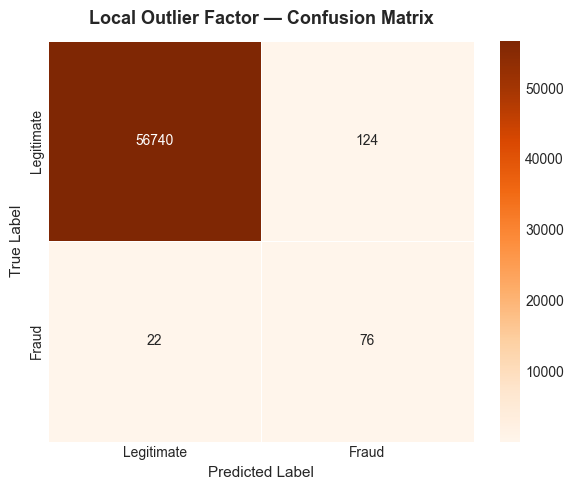

In [41]:
# ============================================================
# CELL 14: LOF — Confusion Matrix
# ============================================================
cm_lof = confusion_matrix(y_test, lof_pred)
fig, ax = plt.subplots(figsize=(6, 5))
plot_confusion_matrix(cm_lof, 'Local Outlier Factor — Confusion Matrix', ax, cmap='Oranges')
plt.tight_layout()
plt.savefig('Graphs/cm_lof.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Supervised Learning — XGBoost with Hyperparameter Tuning and Calibration

We train an XGBoost classifier using SMOTE for handling class imbalance.  
After tuning, we apply isotonic regression to calibrate the predicted probabilities,  
ensuring they reflect true probabilities on the original imbalanced distribution.

In [42]:
# ============================================================
# CELL 15: XGBoost — Hyperparameter space & SMOTE pipeline
# ============================================================

# ── SMOTE + XGBoost pipeline ────────────────────────────────
# scale_pos_weight is not used because SMOTE already rebalances
# the training data inside each cross-validation fold.
smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)

xgb_clf = XGBClassifier(
    objective='binary:logistic',
    eval_metric='aucpr',       # PR-AUC is better for imbalanced data
    use_label_encoder=False,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=0
)

pipeline = ImbPipeline([
    ('smote', smote),
    ('xgb',   xgb_clf)
])

# ── Hyperparameter search space ─────────────────────────────
param_dist = {
    'xgb__n_estimators'       : [100, 200, 300],
    'xgb__max_depth'          : [3, 4, 5, 6],
    'xgb__learning_rate'      : [0.01, 0.05, 0.10, 0.20],
    'xgb__subsample'          : [0.7, 0.8, 0.9, 1.0],
    'xgb__colsample_bytree'   : [0.7, 0.8, 0.9, 1.0],
    'xgb__reg_alpha'          : [0, 0.01, 0.1],    # L1 regularisation
    'xgb__reg_lambda'         : [1.0, 1.5, 2.0],   # L2 regularisation
    'xgb__min_child_weight'   : [1, 3, 5],
    # Using conservative SMOTE ratios (0.3–0.5) to avoid over-aggressive oversampling.
    'smote__sampling_strategy': [0.3, 0.5],
}

# ── Stratified K-Fold cross-validation ──────────────────────
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print('Parameter grid set up. Starting RandomizedSearchCV...')
print('(This may take 5–15 minutes depending on your hardware)')


Parameter grid set up. Starting RandomizedSearchCV...
(This may take 5–15 minutes depending on your hardware)


In [43]:
# ============================================================
# CELL 16: Run RandomizedSearchCV
# ============================================================
import time

random_search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_dist,
    n_iter=30,             # number of random configurations to try
    scoring='f1',          # optimise F1 on the fraud class
    cv=skf,
    refit=True,            # refit the best model on full training data
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

start = time.time()
random_search.fit(X_train, y_train)
elapsed = time.time() - start

print(f'\n✅ Search completed in {elapsed/60:.1f} minutes')
print(f'Best CV F1-Score  : {random_search.best_score_:.4f}')
print('Best Parameters   :')
for k, v in random_search.best_params_.items():
    print(f'  {k:<35} = {v}')

Fitting 5 folds for each of 30 candidates, totalling 150 fits

✅ Search completed in 3.1 minutes
Best CV F1-Score  : 0.8099
Best Parameters   :
  xgb__subsample                      = 0.9
  xgb__reg_lambda                     = 1.0
  xgb__reg_alpha                      = 0.1
  xgb__n_estimators                   = 200
  xgb__min_child_weight               = 1
  xgb__max_depth                      = 6
  xgb__learning_rate                  = 0.2
  xgb__colsample_bytree               = 0.7
  smote__sampling_strategy            = 0.5


In [44]:
# ============================================================
# CELL 17: Calibrate & evaluate the best XGBoost model
# ============================================================
from sklearn.isotonic import IsotonicRegression
from sklearn.base import clone

best_xgb_pipeline = random_search.best_estimator_

# ── CalibratedWrapper ────────────────────────────────────────
# Defined here AND in streamlit_app.py — joblib.load() reconstructs
# the object by looking up __main__.CalibratedWrapper in the current
# namespace, so the definition must exist in both scripts.
#
# IMPORTANT: predict() uses calibrated probabilities (not raw
# self.model.predict()) to avoid SMOTE-inflated scores.
class CalibratedWrapper:
    def __init__(self, model, iso):
        self.model = model   # fitted ImbPipeline
        self.iso   = iso     # fitted IsotonicRegression

    def predict_proba(self, X):
        raw   = self.model.predict_proba(X)[:, 1]
        calib = np.clip(self.iso.predict(raw), 0.0, 1.0)
        return np.vstack([1 - calib, calib]).T

    def predict(self, X, threshold=0.5):
        # Uses calibrated probabilities
        return (self.predict_proba(X)[:, 1] >= threshold).astype(int)

# ── Build calibration split ──────────────────────────────────
# 15% of X_train, real class distribution (no SMOTE), for calibration.
X_tr, X_cal, y_tr, y_cal = train_test_split(
    X_train, y_train,
    test_size=0.15,
    random_state=RANDOM_STATE,
    stratify=y_train
)

pipeline_for_cal = clone(best_xgb_pipeline)
pipeline_for_cal.fit(X_tr, y_tr)          # SMOTE applied only to X_tr

raw_cal_proba = pipeline_for_cal.predict_proba(X_cal)[:, 1]
isotonic_cal  = IsotonicRegression(out_of_bounds='clip')
isotonic_cal.fit(raw_cal_proba, y_cal.values)

calibrated_model = CalibratedWrapper(pipeline_for_cal, isotonic_cal)
print('Probability calibration applied (isotonic regression).')

# ── Evaluate on test set ─────────────────────────────────────
# Both xgb_pred and xgb_proba now use calibrated probabilities
xgb_pred  = calibrated_model.predict(X_test)
xgb_proba = calibrated_model.predict_proba(X_test)[:, 1]

print('=' * 60)
print('XGBOOST (CALIBRATED) — Classification Report (Test Set)')
print('=' * 60)
print(classification_report(y_test, xgb_pred, target_names=['Legitimate', 'Fraud']))

xgb_precision = precision_score(y_test, xgb_pred, zero_division=0)
xgb_recall    = recall_score(y_test, xgb_pred, zero_division=0)
xgb_f1        = f1_score(y_test, xgb_pred, zero_division=0)
xgb_roc_auc   = roc_auc_score(y_test, xgb_proba)

print(f'ROC-AUC Score    : {xgb_roc_auc:.4f}')
print(f'Precision (fraud): {xgb_precision:.4f}')
print(f'Recall    (fraud): {xgb_recall:.4f}')
print(f'F1-Score  (fraud): {xgb_f1:.4f}')

zero_df   = pd.DataFrame([{f: 0.0 for f in FEATURE_NAMES}])
zero_prob = calibrated_model.predict_proba(zero_df)[0, 1]
print(f'\nSanity check — all-zeros fraud probability : {zero_prob*100:.2f}%')
print(f'  (True base rate                           : {y.mean()*100:.4f}%)')


Probability calibration applied (isotonic regression).
XGBOOST (CALIBRATED) — Classification Report (Test Set)
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.90      0.83      0.86        98

    accuracy                           1.00     56962
   macro avg       0.95      0.91      0.93     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC Score    : 0.9767
Precision (fraud): 0.9000
Recall    (fraud): 0.8265
F1-Score  (fraud): 0.8617

Sanity check — all-zeros fraud probability : 4.84%
  (True base rate                           : 0.1727%)


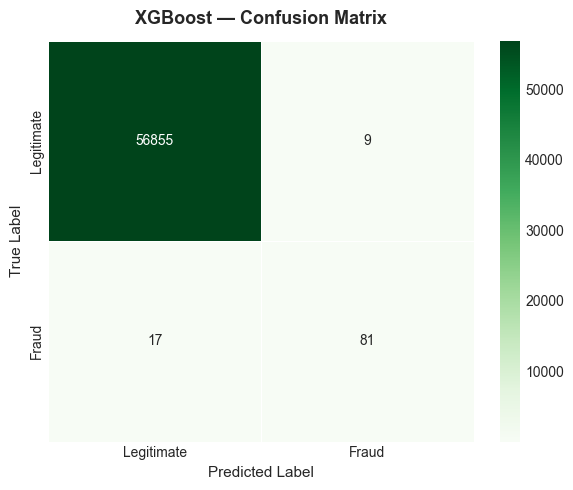

In [45]:
# ============================================================
# CELL 18: XGBoost — Confusion Matrix
# ============================================================
cm_xgb = confusion_matrix(y_test, xgb_pred)
fig, ax = plt.subplots(figsize=(6, 5))
plot_confusion_matrix(cm_xgb, 'XGBoost — Confusion Matrix', ax, cmap='Greens')
plt.tight_layout()
plt.savefig('Graphs/cm_xgboost.png', dpi=150, bbox_inches='tight')
plt.show()

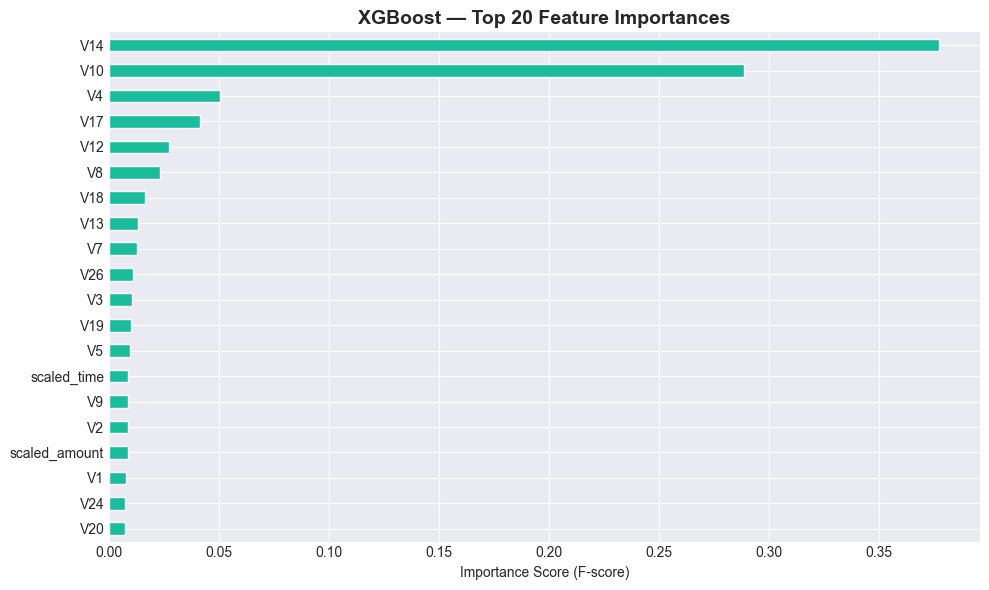

In [46]:
# ============================================================
# CELL 19: XGBoost — Feature Importance (top 20)
# ============================================================
xgb_model = pipeline_for_cal.named_steps['xgb']

feat_imp = pd.Series(
    xgb_model.feature_importances_,
    index=FEATURE_NAMES
).sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 6))
feat_imp.sort_values().plot.barh(ax=ax, color=COLORS['xgb'], edgecolor='white')
ax.set_title('XGBoost — Top 20 Feature Importances', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance Score (F-score)')
plt.tight_layout()
plt.savefig('Graphs/xgb_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 8. Comprehensive Model Evaluation

Side-by-side comparison of all three methods:  
- **ROC Curves** (with AUC scores)  
- **Precision-Recall Curves** (especially informative for imbalanced datasets)  
- **All three Confusion Matrices** together  

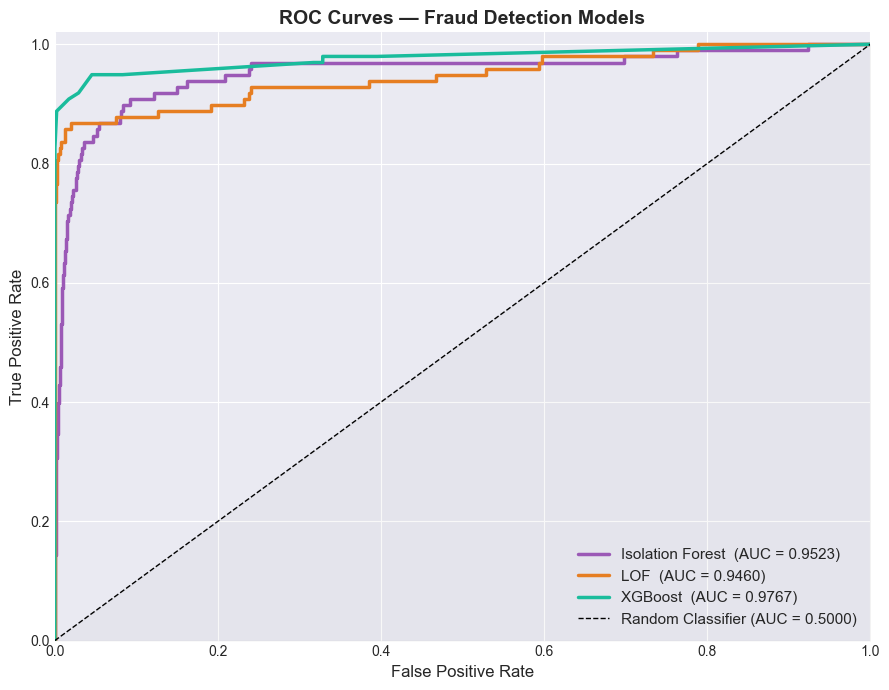

Figure saved: Graphs/roc_curves.png


In [47]:
# ============================================================
# CELL 20: ROC Curves — All three models
# ============================================================
fig, ax = plt.subplots(figsize=(9, 7))

models_roc = [
    ('Isolation Forest', if_scores_norm,  COLORS['if'],  if_roc_auc),
    ('LOF',              lof_scores_norm, COLORS['lof'], lof_roc_auc),
    ('XGBoost',          xgb_proba,       COLORS['xgb'], xgb_roc_auc),
]

for name, scores, color, auc in models_roc:
    fpr, tpr, _ = roc_curve(y_test, scores)
    ax.plot(fpr, tpr, color=color, linewidth=2.5,
            label=f'{name}  (AUC = {auc:.4f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier (AUC = 0.5000)')
ax.fill_between([0, 1], [0, 1], alpha=0.05, color='gray')

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.02])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — Fraud Detection Models', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)

plt.tight_layout()
plt.savefig('Graphs/roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: Graphs/roc_curves.png')

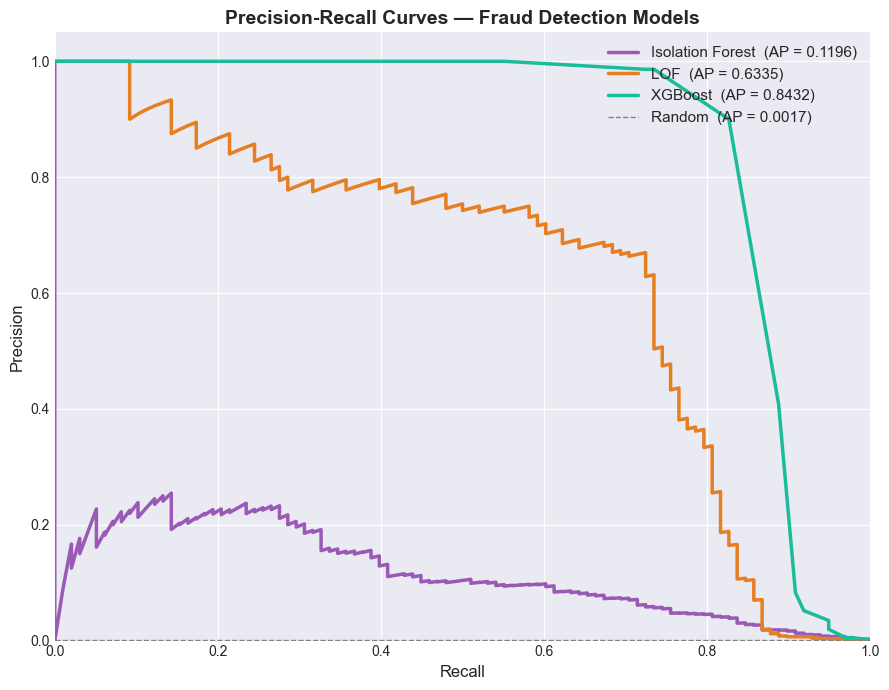

Figure saved: Graphs/pr_curves.png


In [48]:
# ============================================================
# CELL 21: Precision-Recall Curves — All three models
# ============================================================
fig, ax = plt.subplots(figsize=(9, 7))

models_pr = [
    ('Isolation Forest', if_scores_norm,  COLORS['if']),
    ('LOF',              lof_scores_norm, COLORS['lof']),
    ('XGBoost',          xgb_proba,       COLORS['xgb']),
]

for name, scores, color in models_pr:
    prec, rec, _ = precision_recall_curve(y_test, scores)
    ap = average_precision_score(y_test, scores)
    ax.plot(rec, prec, color=color, linewidth=2.5,
            label=f'{name}  (AP = {ap:.4f})')

# Baseline: random classifier AP = fraud prevalence
baseline = y_test.mean()
ax.axhline(baseline, color='gray', linestyle='--', linewidth=1,
           label=f'Random  (AP = {baseline:.4f})')

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curves — Fraud Detection Models', fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=11)

plt.tight_layout()
plt.savefig('Graphs/pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: Graphs/pr_curves.png')

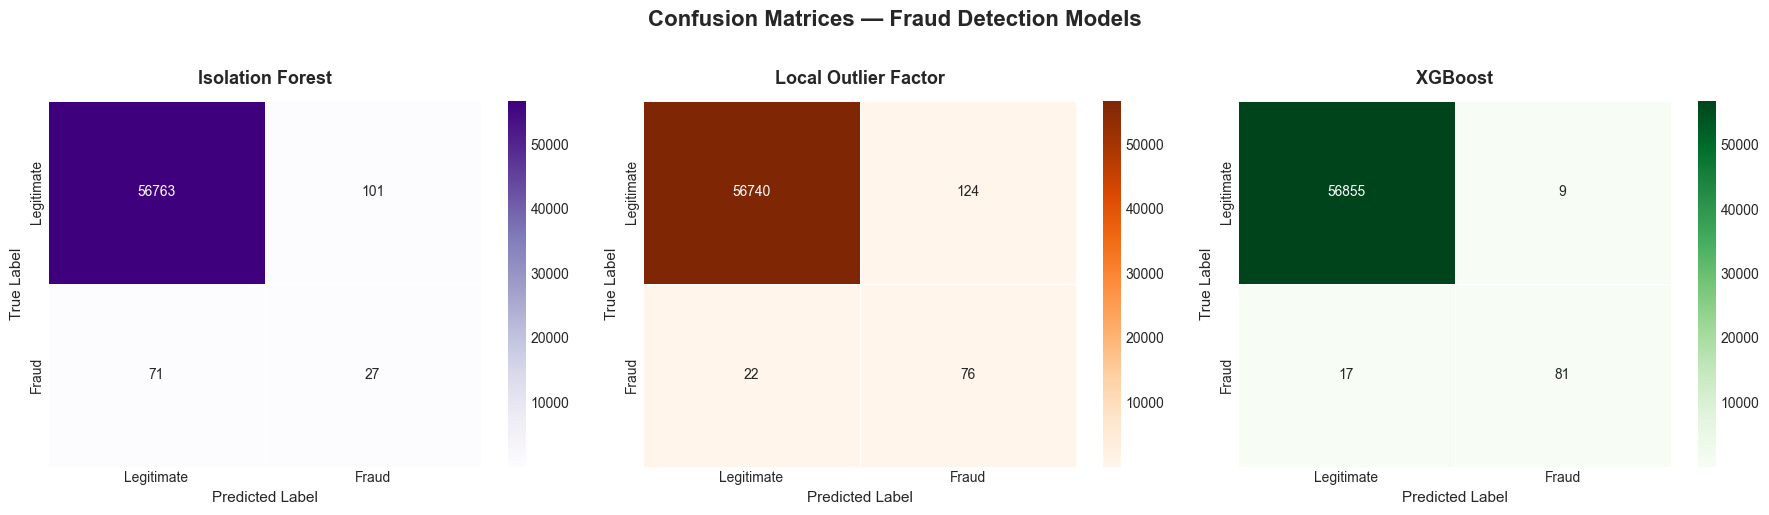

Figure saved: Graphs/confusion_matrices_all.png


In [49]:
# ============================================================
# CELL 22: All Confusion Matrices side by side
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cm_data = [
    (cm_if,  'Isolation Forest', 'Purples'),
    (cm_lof, 'Local Outlier Factor', 'Oranges'),
    (cm_xgb, 'XGBoost', 'Greens'),
]

for ax, (cm, title, cmap) in zip(axes, cm_data):
    plot_confusion_matrix(cm, title, ax, cmap)

plt.suptitle('Confusion Matrices — Fraud Detection Models', fontsize=16,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('Graphs/confusion_matrices_all.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: Graphs/confusion_matrices_all.png')

---
## 9. Final Metrics Summary Table

Side-by-side comparison of all models on key fraud-detection metrics.

In [50]:
# ============================================================
# CELL 23: Build and display the final metrics comparison table
# ============================================================

def compute_tn_fp_fn_tp(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    return tn, fp, fn, tp

rows = []
for name, pred, score_arr, prec, rec, f1, auc in [
    ('Isolation Forest', if_pred,  if_scores_norm,  if_precision,  if_recall,  if_f1,  if_roc_auc),
    ('LOF',              lof_pred, lof_scores_norm, lof_precision, lof_recall, lof_f1, lof_roc_auc),
    ('XGBoost',          xgb_pred, xgb_proba,       xgb_precision, xgb_recall, xgb_f1, xgb_roc_auc),
]:
    tn, fp, fn, tp = compute_tn_fp_fn_tp(y_test, pred)
    ap = average_precision_score(y_test, score_arr)
    rows.append({
        'Model'       : name,
        'Precision'   : round(prec, 4),
        'Recall'      : round(rec,  4),
        'F1-Score'    : round(f1,   4),
        'ROC-AUC'     : round(auc,  4),
        'Avg Precision': round(ap,  4),
        'TP'          : int(tp),
        'FP'          : int(fp),
        'FN'          : int(fn),
        'TN'          : int(tn),
    })

summary_df = pd.DataFrame(rows).set_index('Model')

print('=' * 80)
print('FINAL MODEL COMPARISON — FRAUD DETECTION METRICS')
print('=' * 80)
print(summary_df.to_string())
print()
summary_df

FINAL MODEL COMPARISON — FRAUD DETECTION METRICS
                  Precision  Recall  F1-Score  ROC-AUC  Avg Precision  TP   FP  FN     TN
Model                                                                                    
Isolation Forest     0.2109  0.2755    0.2389   0.9523         0.1196  27  101  71  56763
LOF                  0.3800  0.7755    0.5101   0.9460         0.6335  76  124  22  56740
XGBoost              0.9000  0.8265    0.8617   0.9767         0.8432  81    9  17  56855



,Precision,Recall,F1-Score,ROC-AUC,Avg Precision,TP,FP,FN,TN
Model,,,,,,,,,
Isolation Forest,0.2109,0.2755,0.2389,0.9523,0.1196,27,101,71,56763
LOF,0.3800,0.7755,0.5101,0.9460,0.6335,76,124,22,56740
XGBoost,0.9000,0.8265,0.8617,0.9767,0.8432,81,9,17,56855


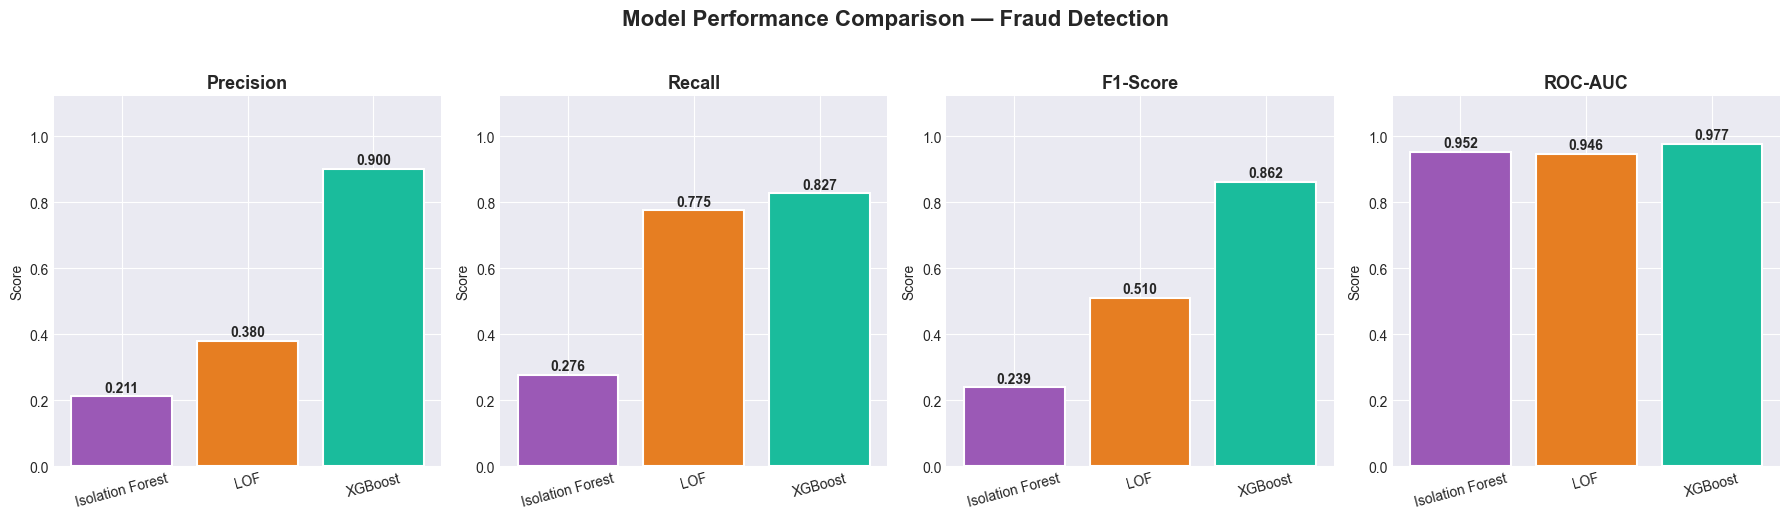

Figure saved: Graphs/metrics_comparison.png


In [51]:
# ============================================================
# CELL 24: Metrics bar chart comparison
# ============================================================
metrics_to_plot = ['Precision', 'Recall', 'F1-Score', 'ROC-AUC']
plot_df = summary_df[metrics_to_plot]

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
model_colors = [COLORS['if'], COLORS['lof'], COLORS['xgb']]

for ax, metric in zip(axes, metrics_to_plot):
    bars = ax.bar(
        plot_df.index, plot_df[metric],
        color=model_colors, edgecolor='white', linewidth=1.5
    )
    for bar, val in zip(bars, plot_df[metric]):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold'
        )
    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_ylim(0, 1.12)
    ax.set_ylabel('Score')
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Model Performance Comparison — Fraud Detection', fontsize=16,
             fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('Graphs/metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: Graphs/metrics_comparison.png')

---
## 10. Save the XGBoost Model & Generate the Streamlit App

We save:
- The **full pipeline** (SMOTE + XGBoost) using `joblib`
- The **feature names** as a JSON file (needed by the Streamlit app)
- The **Streamlit dashboard** as `streamlit_app.py`

In [52]:
# ============================================================
# CELL 25: Save the trained & calibrated model (separate components)
# ============================================================
PIPELINE_PATH  = 'xgboost_pipeline.joblib'
CALIBRATOR_PATH = 'isotonic_calibrator.joblib'
FEATURE_PATH   = 'feature_names.json'

# Save the pipeline and the isotonic calibrator separately
# (This avoids pickling the custom CalibratedWrapper class)
joblib.dump(pipeline_for_cal, PIPELINE_PATH)
joblib.dump(isotonic_cal, CALIBRATOR_PATH)
print(f'Pipeline saved to       : {PIPELINE_PATH}')
print(f'Isotonic calibrator saved to : {CALIBRATOR_PATH}')

# Save feature names
with open(FEATURE_PATH, 'w') as f:
    json.dump(FEATURE_NAMES, f)
print(f'Feature names saved to  : {FEATURE_PATH}')

# ── Verify by loading back ───────────────────────────────────
# Reconstruct the CalibratedWrapper from the two components
pipeline_loaded = joblib.load(PIPELINE_PATH)
iso_loaded = joblib.load(CALIBRATOR_PATH)
loaded_model = CalibratedWrapper(pipeline_loaded, iso_loaded)

test_pred = loaded_model.predict(X_test[:5])
print(f'\nVerification — predictions on 5 test rows: {test_pred}')
print(f'Actual labels                             : {y_test[:5].values}')

zero_df = pd.DataFrame([{f: 0.0 for f in FEATURE_NAMES}])
zero_prob = loaded_model.predict_proba(zero_df)[0, 1]
print(f'\nSanity check after reload — all-zeros fraud prob : {zero_prob*100:.2f}%')
print(f'  (True base rate                                 : {y.mean()*100:.4f}%)')

Pipeline saved to       : xgboost_pipeline.joblib
Isotonic calibrator saved to : isotonic_calibrator.joblib
Feature names saved to  : feature_names.json

Verification — predictions on 5 test rows: [0 0 0 0 0]
Actual labels                             : [0 0 0 0 0]

Sanity check after reload — all-zeros fraud prob : 4.84%
  (True base rate                                 : 0.1727%)


In [53]:
# ============================================================
# CELL 25.5: Save SHAP explainer for model interpretability
# ============================================================
import shap

# Take a background sample (100 random rows from training set)
background = X_train.sample(n=100, random_state=42)

# Extract the underlying XGBoost model from the fitted pipeline
xgb_model = pipeline_for_cal.named_steps['xgb']

# Create a TreeExplainer (optimised for tree-based models)
explainer = shap.TreeExplainer(xgb_model, background)

# Save the explainer and the background dataset for later use in Streamlit
joblib.dump(explainer, "shap_explainer.joblib")
joblib.dump(background, "shap_background.joblib")

print("✅ SHAP explainer and background saved.")

✅ SHAP explainer and background saved.


In [54]:
# ============================================================
# CELL 26: Final summary printout
# ============================================================
print('=' * 70)
print('  PROJECT COMPLETE — CREDIT CARD FRAUD DETECTION PIPELINE')
print('=' * 70)
print()
print('📊 Models Trained:')
print('  1. Isolation Forest (anomaly detection, trained on non-fraud only)')
print('  2. Local Outlier Factor (novelty detection, trained on non-fraud only)')
print('  3. XGBoost + SMOTE pipeline (supervised, with RandomizedSearchCV tuning)')
print()
print('📈 Final Metrics Summary:')
print(summary_df[['Precision','Recall','F1-Score','ROC-AUC']].to_string())
print()
print('💾 Saved Files:')
for fname in ['xgboost_fraud_model.joblib', 'feature_names.json',
              'streamlit_app.py', 'requirements.txt',
              'roc_curves.png', 'pr_curves.png',
              'confusion_matrices_all.png', 'metrics_comparison.png']:
    size = os.path.getsize(fname) if os.path.exists(fname) else 0
    print(f'  {fname:<45} ({size:,} bytes)')
print()
print('🚀 To launch the dashboard:')
print('   streamlit run streamlit_app.py')

  PROJECT COMPLETE — CREDIT CARD FRAUD DETECTION PIPELINE

📊 Models Trained:
  1. Isolation Forest (anomaly detection, trained on non-fraud only)
  2. Local Outlier Factor (novelty detection, trained on non-fraud only)
  3. XGBoost + SMOTE pipeline (supervised, with RandomizedSearchCV tuning)

📈 Final Metrics Summary:
                  Precision  Recall  F1-Score  ROC-AUC
Model                                                 
Isolation Forest     0.2109  0.2755    0.2389   0.9523
LOF                  0.3800  0.7755    0.5101   0.9460
XGBoost              0.9000  0.8265    0.8617   0.9767

💾 Saved Files:
  xgboost_fraud_model.joblib                    (0 bytes)
  feature_names.json                            (219 bytes)
  streamlit_app.py                              (18,412 bytes)
  requirements.txt                              (182 bytes)
  roc_curves.png                                (0 bytes)
  pr_curves.png                                 (0 bytes)
  confusion_matrices_all.png    

## Conclusion

- Successfully developed a machine learning-based system for detecting fraudulent credit card transactions.

- Performed data preprocessing, including handling missing values, feature scaling, and class imbalance management.

- Conducted Exploratory Data Analysis (EDA) to understand transaction patterns and fraud distribution.

- Trained and evaluated multiple classification models to identify fraudulent activities accurately.

- Used performance metrics such as **Accuracy, Precision, Recall, F1-Score, and ROC-AUC** for model evaluation.

- Since fraud datasets are highly imbalanced, **Recall and Precision** were considered more important than accuracy alone.

- The final model showed strong capability in distinguishing fraudulent transactions from legitimate ones.

- Feature importance and model interpretability helped explain why certain transactions were flagged as suspicious.

- This project demonstrates how machine learning can assist financial institutions in reducing fraud-related losses.

- Future improvements can include **real-time fraud detection**, **advanced ensemble models**, and **continuous model retraining** with new transaction data.